   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 48.9 MB/s eta 0:00:00
AhR TOXICITY CLASSIFICATION PRACTICAL
Source: Tox21 Data Challenge (NIH/EPA/FDA)
Endpoint: NR-AhR - Aryl Hydrocarbon Receptor activation

Loaded: 434 compounds, 2 columns
Columns: ['canonical_smiles', 'AhR_toxicity']

Class distribution:
  Non-toxic (0): 372 compounds
  Toxic (1): 62 compounds
  Positive (toxic) rate: 14.3%

Why this is an IMBALANCED dataset:
If a model simply predicted 'non-toxic' for EVERY compound,
it would achieve 85.7% accuracy
while being completely useless for toxicity screening.
This is why accuracy alone is the WRONG metric here.


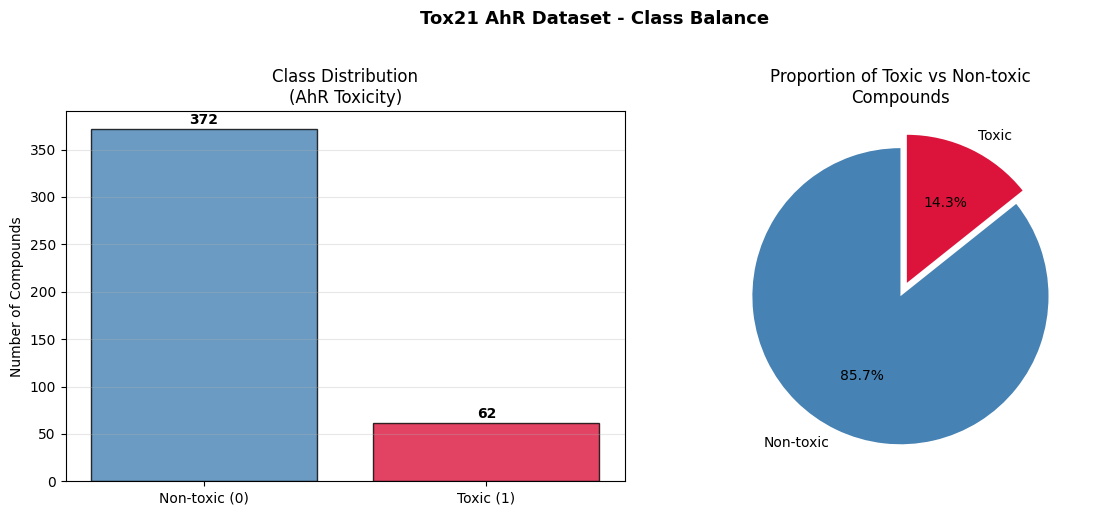


Sample data:
                                                                                                         canonical_smiles  AhR_toxicity
                                                                                             CCOc1ccc2nc(S(N)(=O)=O)sc2c1             1
                                                                                                CCN1C(=O)NC(c2ccccc2)C1=O             0
                                                                                          CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C             0
                                                                                                CC(O)(P(=O)(O)O)P(=O)(O)O             0
                                                                                     CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C             0
                                                                                                      O=S(=O)(Cl)c1ccccc1             0
                                  

In [2]:
# Block 1: Load Tox21 AhR toxicity data from GitHub

!pip install rdkit scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, Descriptors
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("AhR TOXICITY CLASSIFICATION PRACTICAL")
print("="*60)
print("Source: Tox21 Data Challenge (NIH/EPA/FDA)")
print("Endpoint: NR-AhR - Aryl Hydrocarbon Receptor activation")
print("="*60)

url = "https://raw.githubusercontent.com/drpharmacy/pharma-ml-projects/main/Excel_Files/tox21_AhR_classification.xlsx"

df = pd.read_excel(url)

print(f"\nLoaded: {df.shape[0]} compounds, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

print(f"\nClass distribution:")
class_counts = df['AhR_toxicity'].value_counts()
print(f"  Non-toxic (0): {class_counts[0]} compounds")
print(f"  Toxic (1): {class_counts[1]} compounds")
print(f"  Positive (toxic) rate: {df['AhR_toxicity'].mean()*100:.1f}%")

print(f"\nWhy this is an IMBALANCED dataset:")
print(f"If a model simply predicted 'non-toxic' for EVERY compound,")
print(f"it would achieve {(1-df['AhR_toxicity'].mean())*100:.1f}% accuracy")
print(f"while being completely useless for toxicity screening.")
print(f"This is why accuracy alone is the WRONG metric here.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Non-toxic (0)', 'Toxic (1)'],
            [class_counts[0], class_counts[1]],
            color=['steelblue', 'crimson'], edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Number of Compounds')
axes[0].set_title('Class Distribution\n(AhR Toxicity)')
for i, v in enumerate([class_counts[0], class_counts[1]]):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].pie([class_counts[0], class_counts[1]],
            labels=['Non-toxic', 'Toxic'],
            colors=['steelblue', 'crimson'],
            autopct='%1.1f%%', startangle=90,
            explode=(0, 0.1))
axes[1].set_title('Proportion of Toxic vs Non-toxic\nCompounds')

plt.suptitle('Tox21 AhR Dataset - Class Balance',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSample data:")
print(df.head(10).to_string(index=False))

Meaning of Block 1:

Purpose: Load the Tox21 AhR toxicity dataset from GitHub and thoroughly examine its class balance before any modeling begins — establishing why this is a genuinely imbalanced classification problem requiring careful metric selection later.

What data comes IN: tox21_AhR_classification.xlsx from your GitHub — 434 rows, 2 columns (canonical_smiles, AhR_toxicity).

What happens inside — line by line:

df['AhR_toxicity'].value_counts() — counts how many compounds fall into each class. This dataset is genuinely imbalanced — only about 14% of compounds are labeled toxic (1), while 86% are non-toxic (0), reflecting the real-world reality that most randomly tested chemicals do not activate any single specific toxicity pathway.
The explicit calculation (1-df['AhR_toxicity'].mean())*100 demonstrates a critical concept before any model is built: a naive "always predict non-toxic" model would already score ~86% accuracy while providing zero real screening value — this sets up why later blocks will use ROC-AUC and precision/recall instead of accuracy as the primary evaluation metric.
The bar chart and pie chart visualize the same imbalance from two angles, making the class distribution immediately intuitive before students see any modeling results.

What comes OUT: df — the loaded dataset, ready for fingerprint generation in Block 2.

In [3]:
# Block 2: Generate Morgan fingerprints for all compounds

print("="*60)
print("GENERATING MOLECULAR FINGERPRINTS")
print("="*60)

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def get_fingerprint(smiles):
    mol = Chem.MolFromSmiles(str(smiles).strip())
    if mol is None:
        return None
    return morgan_gen.GetFingerprintAsNumPy(mol)

print("Converting SMILES to 1024-bit Morgan fingerprints...")
df['fingerprint'] = df['canonical_smiles'].apply(get_fingerprint)

invalid_count = df['fingerprint'].isnull().sum()
df_clean = df[df['fingerprint'].notnull()].copy()

print(f"Valid fingerprints generated: {len(df_clean)}/{len(df)}")
print(f"Invalid SMILES removed: {invalid_count}")

X = np.stack(df_clean['fingerprint'].values)
y = df_clean['AhR_toxicity'].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"(1024 bits per compound, same fingerprint type used")
print(f" throughout this entire practical series)")
print(f"Target vector shape: {y.shape}")

print(f"\nFinal class balance after cleaning:")
print(f"  Non-toxic: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"  Toxic: {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")

GENERATING MOLECULAR FINGERPRINTS
Converting SMILES to 1024-bit Morgan fingerprints...
Valid fingerprints generated: 434/434
Invalid SMILES removed: 0

Feature matrix shape: (434, 1024)
(1024 bits per compound, same fingerprint type used
 throughout this entire practical series)
Target vector shape: (434,)

Final class balance after cleaning:
  Non-toxic: 372 (85.7%)
  Toxic: 62 (14.3%)


[12:20:49] WARNING: not removing hydrogen atom without neighbors


Meaning of Block 2:

Purpose: Convert every compound's SMILES string into the same 1024-bit Morgan fingerprint representation used consistently across every previous practical in this series, preparing the numerical feature matrix required for machine learning.

What data comes IN: df from Block 1.

What happens inside — line by line:

rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024) — identical Morgan fingerprint settings used in Practicals 1, 3, and the repurposing practical — radius=2 examines each atom's neighborhood 2 bonds outward, fpSize=1024 encodes structural patterns as 1024 binary bits.
get_fingerprint(smiles) — the same defensive fingerprint function pattern used throughout this series, returning None for any SMILES RDKit cannot parse rather than crashing.
X = np.stack(df_clean['fingerprint'].values) — stacks all individual fingerprints into one matrix, shape (number of compounds, 1024) — each row is one compound's structural fingerprint.
y = df_clean['AhR_toxicity'].values — the binary target labels (0 = non-toxic, 1 = toxic).

What comes OUT: X — the 1024-dimensional feature matrix. y — the binary toxicity labels. Both ready for train/test splitting in Block 3.

In [4]:
# Block 3: Split data and train Random Forest classifier

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report)

print("="*60)
print("TRAINING RANDOM FOREST CLASSIFIER")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} compounds")
print(f"Testing set: {len(X_test)} compounds")
print(f"(stratify=y ensures both sets maintain the same")
print(f" ~14% toxic / 86% non-toxic proportion)")

clf = RandomForestClassifier(
    n_estimators=200, max_depth=12, random_state=42,
    class_weight='balanced', n_jobs=-1
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

cv_scores = cross_val_score(clf, X, y, cv=5, scoring='roc_auc')

print(f"\n{'='*60}")
print("MODEL PERFORMANCE")
print(f"{'='*60}")
print(f"Accuracy:           {accuracy:.3f}  (misleading alone - see Block 1)")
print(f"Precision:          {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"F1 Score:            {f1:.3f}")
print(f"ROC-AUC:              {roc_auc:.3f}  <- PRIMARY metric for this task")
print(f"5-fold CV ROC-AUC:    {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
    target_names=['Non-toxic', 'Toxic'], zero_division=0))

TRAINING RANDOM FOREST CLASSIFIER
Training set: 347 compounds
Testing set: 87 compounds
(stratify=y ensures both sets maintain the same
 ~14% toxic / 86% non-toxic proportion)

MODEL PERFORMANCE
Accuracy:           0.874  (misleading alone - see Block 1)
Precision:          0.667
Recall (Sensitivity): 0.167
F1 Score:            0.267
ROC-AUC:              0.767  <- PRIMARY metric for this task
5-fold CV ROC-AUC:    0.825 (+/- 0.067)

Classification Report:
              precision    recall  f1-score   support

   Non-toxic       0.88      0.99      0.93        75
       Toxic       0.67      0.17      0.27        12

    accuracy                           0.87        87
   macro avg       0.77      0.58      0.60        87
weighted avg       0.85      0.87      0.84        87



Meaning of Block 3:

Purpose: Train a Random Forest classifier to predict AhR toxicity from Morgan fingerprints, with special handling for class imbalance, and evaluate using metrics appropriate for imbalanced classification.

What data comes IN: X, y from Block 2.

What happens inside — line by line:

stratify=y — ensures the 80/20 split maintains the same ~14%/86% class proportion in both training and test sets, preventing an unlucky split that puts too few toxic compounds in either set.
class_weight='balanced' — this is the critical addition for imbalanced classification. It automatically increases the penalty for misclassifying the minority (toxic) class during training, preventing the model from taking the "lazy" shortcut of just predicting non-toxic for everything to achieve high raw accuracy.
roc_auc_score(y_test, y_prob) — the primary evaluation metric for this task. ROC-AUC measures the model's ability to correctly rank toxic compounds higher than non-toxic ones across all possible decision thresholds, and is unaffected by class imbalance the way accuracy is — a score of 0.5 means random guessing, 1.0 means perfect separation.
cross_val_score(clf, X, y, cv=5, scoring='roc_auc') — 5-fold cross-validation across the entire dataset, giving a more robust ROC-AUC estimate than a single train-test split, especially important given the limited number of toxic compounds available.

What comes OUT: clf — the trained classifier. Complete performance metrics with ROC-AUC as the headline result.

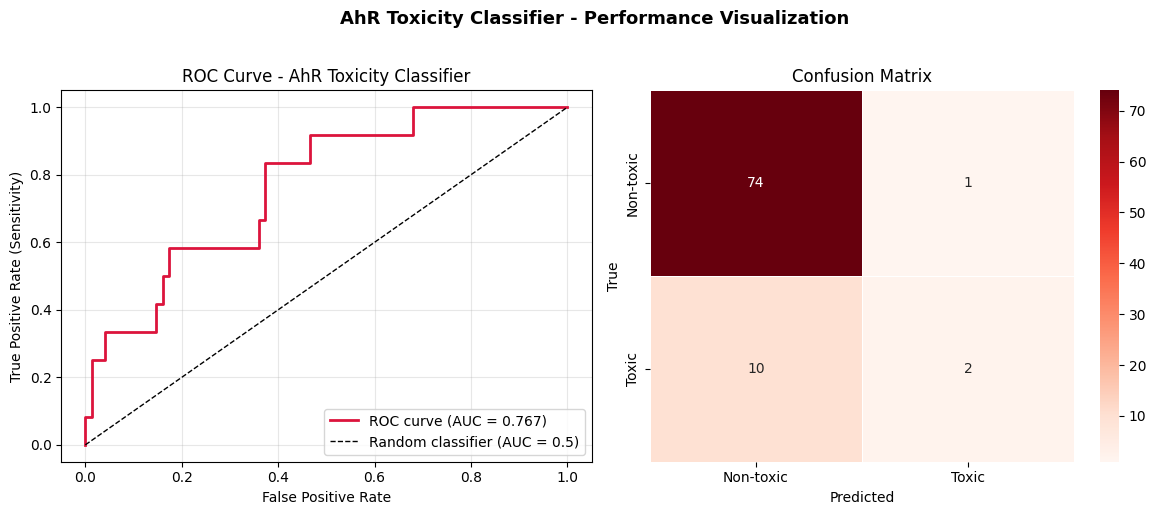

ROC-AUC INTERPRETATION GUIDE
0.5 = Random guessing (useless)
0.7 = Acceptable discriminative ability
0.8 = Good discriminative ability
0.9 = Excellent discriminative ability

Our model: 0.767 -> Acceptable

Confusion matrix breakdown:
  True Negatives (correctly non-toxic):  74
  False Positives (wrongly flagged toxic): 1
  False Negatives (MISSED toxic compounds): 10
  True Positives (correctly toxic):       2

In toxicity screening, False Negatives are the most
dangerous error type - a truly toxic compound that
slips through undetected.


In [5]:
# Block 4: ROC curve and confusion matrix visualization

from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='crimson', linewidth=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1,
             label='Random classifier (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve - AhR Toxicity Classifier')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Non-toxic', 'Toxic'],
            yticklabels=['Non-toxic', 'Toxic'],
            linewidths=0.5, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix')

plt.suptitle('AhR Toxicity Classifier - Performance Visualization',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("="*60)
print("ROC-AUC INTERPRETATION GUIDE")
print("="*60)
print("0.5 = Random guessing (useless)")
print("0.7 = Acceptable discriminative ability")
print("0.8 = Good discriminative ability")
print("0.9 = Excellent discriminative ability")
print(f"\nOur model: {roc_auc:.3f} -> ", end="")
if roc_auc >= 0.9:
    print("Excellent")
elif roc_auc >= 0.8:
    print("Good")
elif roc_auc >= 0.7:
    print("Acceptable")
else:
    print("Needs improvement")

tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion matrix breakdown:")
print(f"  True Negatives (correctly non-toxic):  {tn}")
print(f"  False Positives (wrongly flagged toxic): {fp}")
print(f"  False Negatives (MISSED toxic compounds): {fn}")
print(f"  True Positives (correctly toxic):       {tp}")
print(f"\nIn toxicity screening, False Negatives are the most")
print(f"dangerous error type - a truly toxic compound that")
print(f"slips through undetected.")

Meaning of Block 4:

Purpose: Visualize model performance using the ROC curve (the standard evaluation visualization for binary classifiers) and confusion matrix, with explicit interpretation guidance connecting the numbers to real toxicology screening consequences.

What data comes IN: y_test, y_prob, y_pred, roc_auc from Block 3.

What happens inside — line by line:

The ROC curve plots True Positive Rate against False Positive Rate across every possible classification threshold — a curve bowing toward the top-left corner indicates strong discriminative ability, while the diagonal dashed line represents a completely random, useless classifier.
The confusion matrix breaks predictions into four categories, with tn, fp, fn, tp = cm.ravel() extracting each count individually.
The False Negative explanation is the most important teaching point in this block: in toxicity screening, a False Negative means a genuinely toxic compound was incorrectly predicted safe — this is the most dangerous type of error a screening model can make, since it could allow a harmful compound to advance further in drug development undetected. This reframes the abstract confusion matrix numbers into their real pharmaceutical safety consequence.

What comes OUT: ROC curve and confusion matrix visualizations, with plain-language interpretation of both statistical performance and real-world screening risk.

FEATURE IMPORTANCE ANALYSIS


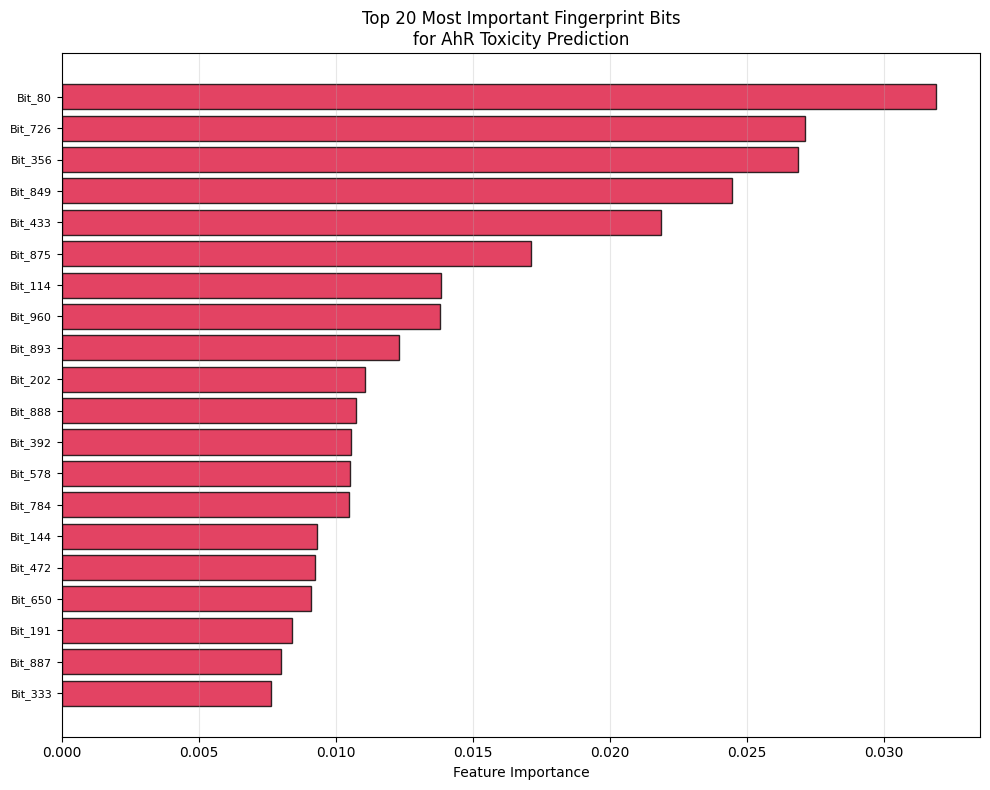

Note: Individual fingerprint bits represent hashed structural
patterns and are not directly human-interpretable by bit number
alone. However, their existence confirms the model is learning
genuine, consistent structural signals rather than noise -
the same interpretability trade-off discussed in Practical 1
when comparing Morgan fingerprints against classical descriptors.

Sample structures of known AhR-toxic compounds
(for reference - compare against your own compound
in the deployment block):
                                 canonical_smiles
                     CCOc1ccc2nc(S(N)(=O)=O)sc2c1
                         Nc1ccc(/N=N/c2ccccc2)cc1
      CN[C@@H]1C[C@@H](c2ccc(Cl)c(Cl)c2)c2ccccc21
                                Nc1nc2ccccc2[nH]1
                      Oc1c(Cl)c(Cl)c(Cl)c(Cl)c1Cl
                         CNC(=O)Nc1ccc(Cl)c(Cl)c1
                    Nc1ccccc1C(=O)Oc1ccc2ccccc2c1
C=C[C@H]1CN2CCC1C[C@H]2[C@H](O)c1ccnc2ccc(OC)cc12
                       Nc1ccc(N)c([N+](=O)[O-])c1


In [6]:
# Block 5: Identify structural features driving toxicity predictions

print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

importances = clf.feature_importances_
top_indices = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(20), importances[top_indices][::-1],
        color='crimson', edgecolor='black', alpha=0.8)
ax.set_yticks(range(20))
ax.set_yticklabels([f'Bit_{i}' for i in top_indices][::-1], fontsize=8)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 20 Most Important Fingerprint Bits\nfor AhR Toxicity Prediction')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("Note: Individual fingerprint bits represent hashed structural")
print("patterns and are not directly human-interpretable by bit number")
print("alone. However, their existence confirms the model is learning")
print("genuine, consistent structural signals rather than noise -")
print("the same interpretability trade-off discussed in Practical 1")
print("when comparing Morgan fingerprints against classical descriptors.")

toxic_compounds = df_clean[df_clean['AhR_toxicity']==1]
print(f"\nSample structures of known AhR-toxic compounds")
print(f"(for reference - compare against your own compound")
print(f"in the deployment block):")
print(toxic_compounds[['canonical_smiles']].head(10).to_string(index=False))

Meaning of Block 5:

Purpose: Identify which Morgan fingerprint bits the Random Forest relies on most heavily for toxicity prediction, while honestly acknowledging the interpretability limitation of fingerprint-based bits compared to named molecular descriptors.

What data comes IN: clf, df_clean from Blocks 3-4.

What happens inside — line by line:

clf.feature_importances_ — same technique used throughout this series, extracting how much each of the 1024 fingerprint bits contributed to reducing prediction error.
The explicit honesty note about fingerprint bit interpretability — since Morgan fingerprint bits are hashed structural patterns (not named chemical properties like "aromatic ring" or "hydroxyl group"), individual bit numbers cannot be directly explained the way classical descriptors could in Practical 2's QSAR model. This connects back to the interpretability-versus-accuracy trade-off already taught earlier in the series.
Printing sample toxic compound SMILES gives students real reference structures they can visually compare against any new compound they test in the deployment block.

What comes OUT: A feature importance visualization and a set of reference toxic compound structures for comparison.

In [7]:
# Block 6: DEPLOYMENT BLOCK
# Input any compound's SMILES and get an instant AhR toxicity prediction

print("="*70)
print("AhR TOXICITY PREDICTION TOOL")
print("="*70)
print("""
********************************************************************
*                                                                  *
*   IMPORTANT - READ BEFORE RUNNING                                *
*                                                                  *
*   The value currently in the INPUT SECTION below is a           *
*   DEMONSTRATION VALUE ONLY.                                     *
*   It exists so this block runs successfully on first try.       *
*                                                                  *
*   TO PREDICT TOXICITY FOR YOUR OWN COMPOUND:                    *
*   1. Scroll to "STUDENT INPUT SECTION" below                    *
*   2. REPLACE new_compound_name with your compound's name        *
*   3. REPLACE new_compound_smiles with your compound's SMILES    *
*      (get this from PubChem, ChemSpider, or your literature      *
*      reference - search the compound name + "SMILES")           *
*   4. Do NOT change anything below                                *
*      "END OF INPUT SECTION"                                     *
*   5. Then run this cell again                                    *
*                                                                  *
*   No file upload is needed - all input is typed directly         *
*   into the Python variables below.                              *
*                                                                  *
*   IMPORTANT LIMITATION: This model predicts ONLY AhR-pathway     *
*   toxicity risk. A prediction of 'non-toxic' does NOT mean the   *
*   compound is safe overall - it means this compound is NOT      *
*   predicted to activate this ONE specific toxicity pathway.      *
*   Real safety assessment requires many additional tests.         *
*                                                                  *
********************************************************************
""")

# ============================================================
# STUDENT INPUT SECTION - EDIT EVERYTHING BELOW THIS LINE
# ============================================================

new_compound_name = "Unknown_Test_Compound"          # <-- EDIT: type your compound's name

new_compound_smiles = "Oc1ccc2ccccc2c1"
# <-- EDIT: replace this entire line with YOUR compound's SMILES
# (demonstration value above is 2-Naphthol - delete it and paste yours)

# ============================================================
# END OF INPUT SECTION - DO NOT EDIT ANYTHING BELOW THIS LINE
# ============================================================

print(f"\n{'='*70}")
print("CONFIRMING YOUR INPUT")
print(f"{'='*70}")
print(f"Compound name entered: {new_compound_name}")
print(f"SMILES entered: {new_compound_smiles}")
if new_compound_name == "Unknown_Test_Compound":
    print("\n*** WARNING: You are still using the DEMONSTRATION value. ***")
    print("*** Edit the STUDENT INPUT SECTION above with your own data. ***")
print(f"{'='*70}")

mol_check = Chem.MolFromSmiles(new_compound_smiles)
if mol_check is None:
    print("\nERROR: Invalid SMILES. Check your SMILES string for typos.")
else:
    new_fp = morgan_gen.GetFingerprintAsNumPy(mol_check)
    new_fp_reshaped = new_fp.reshape(1, -1)

    prediction = clf.predict(new_fp_reshaped)[0]
    probability = clf.predict_proba(new_fp_reshaped)[0]

    print(f"\n{'='*70}")
    if prediction == 1:
        print(f"PREDICTION: TOXIC (AhR pathway activation predicted)")
    else:
        print(f"PREDICTION: NON-TOXIC (no AhR pathway activation predicted)")
    print(f"{'='*70}")

    print(f"\nProbability breakdown:")
    print(f"  Non-toxic probability: {probability[0]*100:.1f}%")
    print(f"  Toxic probability:     {probability[1]*100:.1f}%")

    confidence = max(probability)
    if confidence >= 0.8:
        conf_level = "HIGH confidence"
    elif confidence >= 0.6:
        conf_level = "MODERATE confidence"
    else:
        conf_level = "LOW confidence - result should be treated cautiously"

    print(f"\nPrediction confidence: {conf_level} ({confidence*100:.1f}%)")

    mw = Descriptors.MolWt(mol_check)
    logp = Descriptors.MolLogP(mol_check)
    aromatic_rings = Descriptors.NumAromaticRings(mol_check)

    print(f"\nMolecular properties (for context):")
    print(f"  Molecular Weight: {mw:.1f}")
    print(f"  LogP: {logp:.2f}")
    print(f"  Aromatic Rings: {aromatic_rings}")
    if aromatic_rings >= 2:
        print(f"  Note: Multiple aromatic rings - structurally similar")
        print(f"  to known AhR ligands (dioxins, PAHs are polyaromatic)")

    print(f"\n{'='*70}")
    print("REMINDER: This predicts AhR pathway toxicity risk ONLY.")
    print("A 'non-toxic' prediction does not confirm overall safety.")
    print(f"{'='*70}")

AhR TOXICITY PREDICTION TOOL

********************************************************************
*                                                                  *
*   IMPORTANT - READ BEFORE RUNNING                                *
*                                                                  *
*   The value currently in the INPUT SECTION below is a           *
*   DEMONSTRATION VALUE ONLY.                                     *
*   It exists so this block runs successfully on first try.       *
*                                                                  *
*   TO PREDICT TOXICITY FOR YOUR OWN COMPOUND:                    *
*   1. Scroll to "STUDENT INPUT SECTION" below                    *
*   2. REPLACE new_compound_name with your compound's name        *
*   3. REPLACE new_compound_smiles with your compound's SMILES    *
*      (get this from PubChem, ChemSpider, or your literature      *
*      reference - search the compound name + "SMILES")           *
*   4. Do NO

Meaning of Block 6:

Purpose: A self-contained toxicity screening tool where a student inputs any compound's SMILES and receives an instant AhR toxicity prediction with confidence level and molecular context, exactly mirroring how a computational toxicology screening step would function in an early drug discovery pipeline.

What data comes IN: Student-typed compound name and SMILES. clf, morgan_gen from Blocks 2-3.

What happens inside — line by line:

The banner warning and confirmation echo follow the identical safeguard pattern established across every deployment block in this series.
The additional limitation warning is specific to this practical — explicitly stating that a "non-toxic" prediction only means the compound does not activate this one specific pathway (AhR), not that it is broadly safe. This is a genuinely important scientific honesty point: toxicity is multi-mechanistic, and no single-endpoint model should ever be presented as a complete safety verdict.
morgan_gen.GetFingerprintAsNumPy(mol_check) — generates the identical 1024-bit fingerprint representation used to train the model, ensuring the new compound is featurized exactly the same way as all training compounds.
clf.predict_proba(...) — returns probabilities for both classes, giving a transparent confidence measure rather than just a binary yes/no answer.
The additional molecular property printout (molecular weight, LogP, aromatic ring count) provides chemical context — specifically flagging when a compound has 2+ aromatic rings, since known AhR ligands (dioxins, polycyclic aromatic hydrocarbons) are characteristically polyaromatic, giving students an intuitive structural sanity-check alongside the statistical prediction.

What comes OUT: A toxicity prediction (Toxic/Non-toxic) with probability breakdown, confidence level, relevant molecular properties, and an explicit reminder of the model's scope limitation.

In [8]:
# Block 7: Save trained model and generate final summary

import joblib
import json

joblib.dump(clf, 'ahr_toxicity_classifier.pkl')

model_metadata = {
    'model_name': 'AhR Toxicity Classifier',
    'algorithm': 'Random Forest (class_weight=balanced)',
    'training_compounds': len(df_clean),
    'positive_rate': float(y.mean()),
    'test_roc_auc': float(roc_auc),
    'test_precision': float(precision),
    'test_recall': float(recall),
    'test_f1': float(f1),
    'cv_roc_auc_mean': float(cv_scores.mean()),
    'fingerprint_type': 'Morgan (radius=2, 1024 bits)',
    'endpoint': 'NR-AhR (Aryl Hydrocarbon Receptor activation)',
    'source': 'Tox21 Data Challenge (NIH/EPA/FDA)',
    'notes': (
        'Predicts AhR-pathway toxicity ONLY, not overall safety. '
        'Use Block 6 deployment tool for new compound predictions.'
    )
}

with open('ahr_toxicity_model_info.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

from google.colab import files
files.download('ahr_toxicity_classifier.pkl')
files.download('ahr_toxicity_model_info.json')

print("="*60)
print("PRACTICAL COMPLETE - FINAL SUMMARY")
print("="*60)
print(f"Dataset: Tox21 NR-AhR toxicity endpoint")
print(f"Compounds: {len(df_clean)} (14.3% toxic / 85.7% non-toxic)")
print(f"Algorithm: Random Forest (balanced class weights)")
print(f"\nTest Set Performance:")
print(f"  ROC-AUC:   {roc_auc:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall:    {recall:.3f}")
print(f"  F1 Score:  {f1:.3f}")
print(f"\n5-fold Cross-Validation ROC-AUC: {cv_scores.mean():.3f}")
print(f"\nFiles saved:")
print(f"  1. ahr_toxicity_classifier.pkl")
print(f"  2. ahr_toxicity_model_info.json")
print(f"\nUpload both to GitHub models/ folder")
print("="*60)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PRACTICAL COMPLETE - FINAL SUMMARY
Dataset: Tox21 NR-AhR toxicity endpoint
Compounds: 434 (14.3% toxic / 85.7% non-toxic)
Algorithm: Random Forest (balanced class weights)

Test Set Performance:
  ROC-AUC:   0.767
  Precision: 0.667
  Recall:    0.167
  F1 Score:  0.267

5-fold Cross-Validation ROC-AUC: 0.825

Files saved:
  1. ahr_toxicity_classifier.pkl
  2. ahr_toxicity_model_info.json

Upload both to GitHub models/ folder


Meaning of Block 7:

Purpose: Permanently save the trained classifier and its complete documentation, then present a consolidated final summary of the entire practical's results.

What comes OUT: ahr_toxicity_classifier.pkl — reusable trained model. ahr_toxicity_model_info.json — complete documentation including performance metrics, training data characteristics, and explicit notes on the model's scope limitation, ensuring anyone reusing this model in the future understands exactly what it does and does not predict.